# ДЗ 2.3. Связанные колебания и жёсткость (Зелёный уровень)

## Постановка задачи
Рассматриваются две одинаковые массы $m$, соединённые пружинами с неподвижными опорами. Между массами находится дополнительная пружина и демпфер.
В общем случае (с демпфированием $c \neq 0$) уравнения движения имеют вид:

$$m\ddot{x}_1 = -k_0 x_1 - k_c (x_1 - x_2) - c(\dot{x}_1 - \dot{x}_2)$$
$$m\ddot{x}_2 = -k_0 x_2 - k_c (x_2 - x_1) - c(\dot{x}_2 - \dot{x}_1)$$

**Условия нашей задачи:** слабая связь $k_c \ll k_0$, демпфирование отсутствует $c = 0$.
Тогда система упрощается до:

$$m\ddot{x}_1 = -k_0 x_1 - k_c (x_1 - x_2)$$
$$m\ddot{x}_2 = -k_0 x_2 - k_c (x_2 - x_1)$$

## Сведение к системе первого порядка
Обозначим скорости: $v_1 = \dot{x}_1$, $v_2 = \dot{x}_2$.
Тогда система двух уравнений второго порядка сводится к системе четырёх уравнений первого порядка:

$$
\begin{cases}
\dot{x}_1 = v_1 \\
\dot{v}_1 = \dfrac{1}{m}\bigl(-k_0 x_1 - k_c (x_1 - x_2)\bigr) \\
\dot{x}_2 = v_2 \\
\dot{v}_2 = \dfrac{1}{m}\bigl(-k_0 x_2 - k_c (x_2 - x_1)\bigr)
\end{cases}
$$

Вектор состояния: $s = [x_1, v_1, x_2, v_2]^T$.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import hilbert

# Параметры системы
m = 1.0
k0 = 10.0     # жёсткость пружин, соединяющих с опорами
kc = 1.0      # жёсткость соединительной пружины (слабая связь: kc << k0)
c = 0.0       # коэффициент демпфирования

# Начальные условия: возбуждаем смещением одной массы, вторая в покое
x1_0, v1_0 = 1.0, 0.0
x2_0, v2_0 = 0.0, 0.0

s0 = np.array([x1_0, v1_0, x2_0, v2_0], dtype=np.float64)

# Функции интегрирования

In [8]:
def rhs_coupled(state):
    """Правая часть системы связанных колебаний (c=0)."""
    x1, v1, x2, v2 = state
    a1 = (-k0 * x1 - kc * (x1 - x2)) / m
    a2 = (-k0 * x2 - kc * (x2 - x1)) / m
    return np.array([v1, a1, v2, a2])

def step_rk4(state, dt):
    """Классический RK4."""
    k1 = rhs_coupled(state)
    k2 = rhs_coupled(state + dt * k1 / 2)
    k3 = rhs_coupled(state + dt * k2 / 2)
    k4 = rhs_coupled(state + dt * k3)
    return state + dt * (k1 + 2*k2 + 2*k3 + k4) / 6

def step_verlet(state, dt):
    """Метод Верле (скоростная форма)."""
    x1, v1, x2, v2 = state
    
    a1 = (-k0 * x1 - kc * (x1 - x2)) / m
    a2 = (-k0 * x2 - kc * (x2 - x1)) / m
    
    v1_half = v1 + a1 * dt / 2
    v2_half = v2 + a2 * dt / 2
    
    x1_new = x1 + v1_half * dt
    x2_new = x2 + v2_half * dt
    
    a1_new = (-k0 * x1_new - kc * (x1_new - x2_new)) / m
    a2_new = (-k0 * x2_new - kc * (x2_new - x1_new)) / m
    
    v1_new = v1_half + a1_new * dt / 2
    v2_new = v2_half + a2_new * dt / 2
    
    return np.array([x1_new, v1_new, x2_new, v2_new])

def simulate(step_func, s0, dt, t_end):
    """Интегратор."""
    n_steps = int(round(t_end / dt))
    t = np.linspace(0.0, t_end, n_steps + 1)
    states = np.zeros((n_steps + 1, 4), dtype=np.float64)
    states[0] = s0
    for i in range(1, n_steps + 1):
        states[i] = step_func(states[i - 1], dt)
    return t, states

# Графики смещений

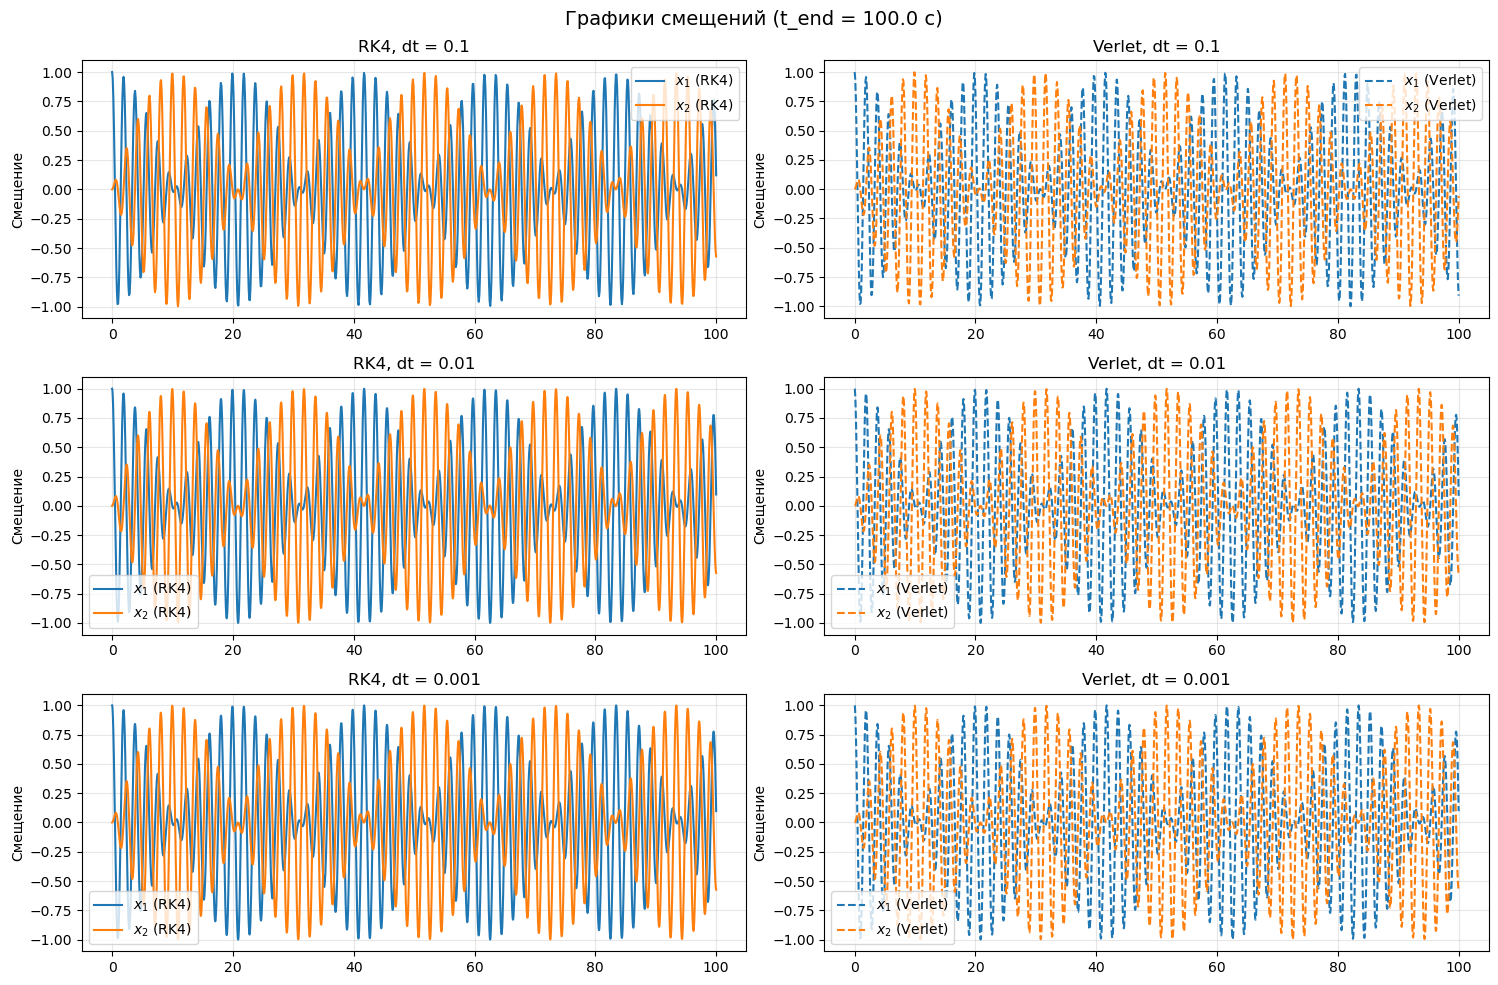

In [9]:
dt_list = [0.1, 0.01, 0.001]
t_end_plot = 100.0

results_plot = {}

for dt in dt_list:
    for name, step_func in [("RK4", step_rk4), ("Verlet", step_verlet)]:
        t, states = simulate(step_func, s0, dt, t_end_plot)
        results_plot[(name, dt)] = (t, states)

fig, axes = plt.subplots(len(dt_list), 2, figsize=(15, 10))

for i, dt in enumerate(dt_list):
    t, states_rk4 = results_plot[("RK4", dt)]
    x1_rk4 = states_rk4[:, 0]
    x2_rk4 = states_rk4[:, 2]
    
    t, states_verlet = results_plot[("Verlet", dt)]
    x1_verlet = states_verlet[:, 0]
    x2_verlet = states_verlet[:, 2]
    
    axes[i, 0].plot(t, x1_rk4, label=r'$x_1$ (RK4)', color='tab:blue')
    axes[i, 0].plot(t, x2_rk4, label=r'$x_2$ (RK4)', color='tab:orange')
    axes[i, 0].set_title(f'RK4, dt = {dt}')
    axes[i, 0].set_ylabel('Смещение')
    axes[i, 0].legend()
    axes[i, 0].grid(alpha=0.3)
    
    axes[i, 1].plot(t, x1_verlet, label=r'$x_1$ (Verlet)', color='tab:blue', linestyle='--')
    axes[i, 1].plot(t, x2_verlet, label=r'$x_2$ (Verlet)', color='tab:orange', linestyle='--')
    axes[i, 1].set_title(f'Verlet, dt = {dt}')
    axes[i, 1].set_ylabel('Смещение')
    axes[i, 1].legend()
    axes[i, 1].grid(alpha=0.3)

plt.suptitle(f'Графики смещений (t_end = {t_end_plot} с)', fontsize=14)
plt.tight_layout()
plt.show()

# Обзорный график биений

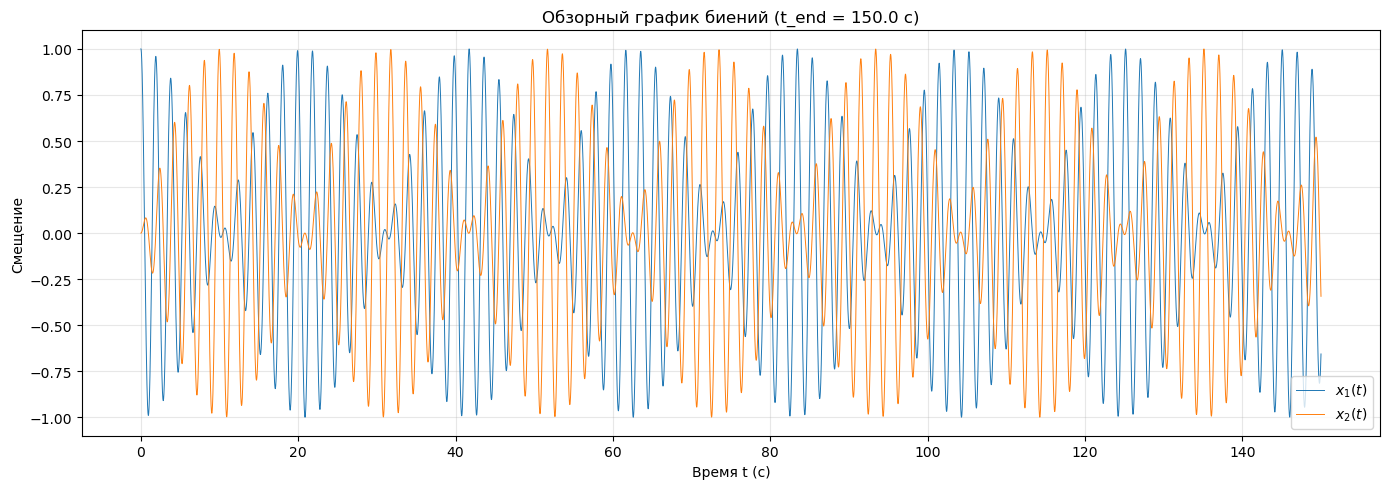

In [10]:
# Обзорный график биений
t_end_overview = 150.0
t_ov, states_ov = simulate(step_rk4, s0, 0.001, t_end_overview)
x1_ov = states_ov[:, 0]
x2_ov = states_ov[:, 2]

plt.figure(figsize=(14, 5))
plt.plot(t_ov, x1_ov, label=r'$x_1(t)$', color='tab:blue', lw=0.7)
plt.plot(t_ov, x2_ov, label=r'$x_2(t)$', color='tab:orange', lw=0.7)
plt.xlabel('Время t (с)')
plt.ylabel('Смещение')
plt.title(f'Обзорный график биений (t_end = {t_end_overview} с)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Анализ частот: FFT по сигналу и огибающей

Собственные частоты:
  omega1 (синфазная)      = 3.1623 рад/с
  omega2 (противофазная)  = 3.4641 рад/с
  omega_beat (биения)     = 0.1509 рад/с
  Период биений           = 41.6348 с

--- FFT по сигналу x1(t) ---
  Теория omega1 = 3.1623  ->  пик FFT = 3.1130
  Теория omega2 = 3.4641  ->  пик FFT = 3.4160


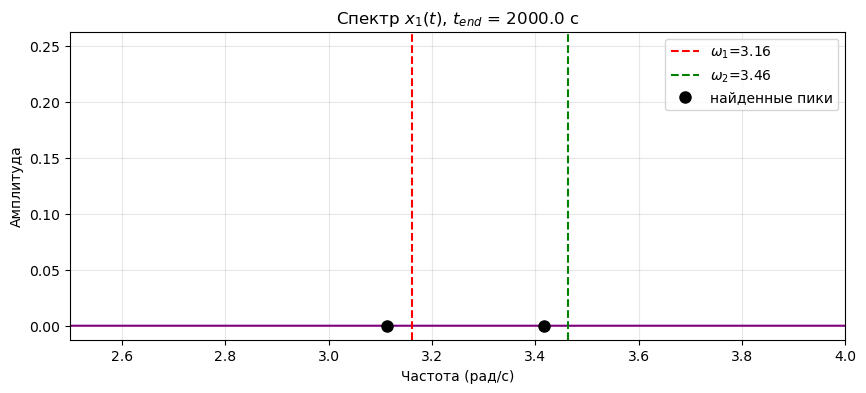


--- FFT по огибающей |x1(t)| ---
  Теория omega_beat = 0.1509  ->  пик FFT = 0.1441


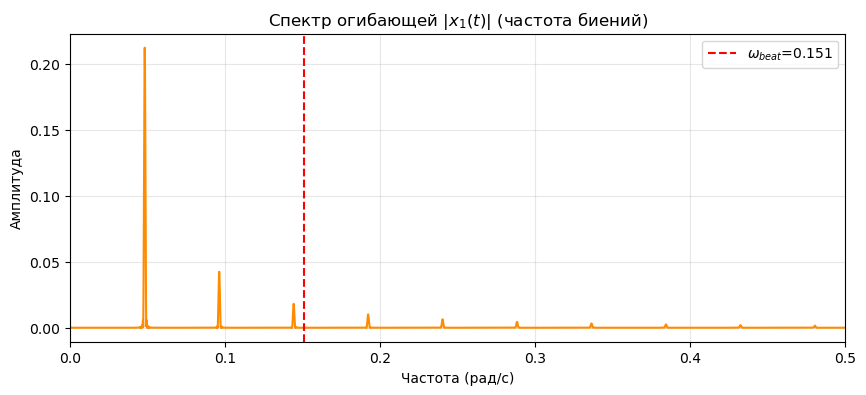


--- Сравнение с аналитикой ---
  Максимальная ошибка = 6.786e-09
  (машинная точность ~ 1e-16, шаг dt = 0.001)


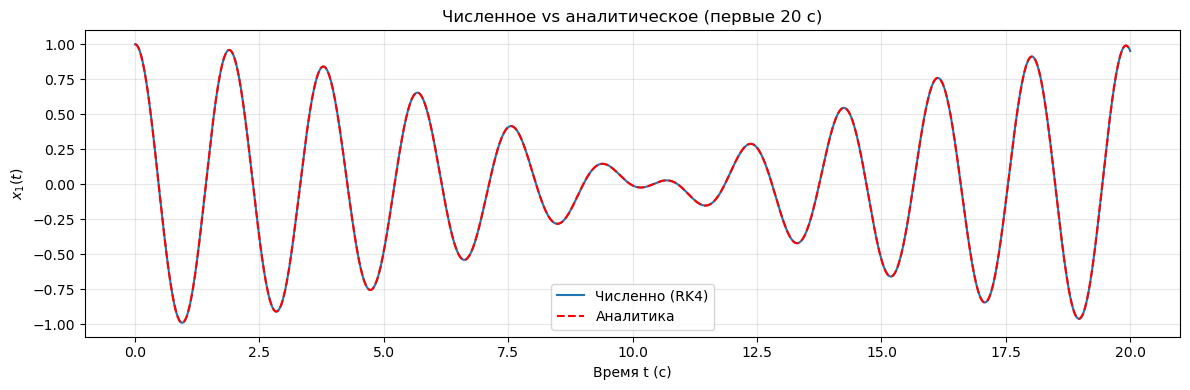

In [11]:
# ============================================================
# FFT: анализ сигнала и огибающей
# ============================================================
dt = 0.001
t_end_fft = 2000.0
t_fft, states_fft = simulate(step_rk4, s0, dt, t_end_fft)
x1_fft = states_fft[:, 0]

# Собственные частоты системы (аналитически)
omega1 = np.sqrt(k0 / m)
omega2 = np.sqrt((k0 + 2 * kc) / m)
omega_beat = (omega2 - omega1) / 2

print("Собственные частоты:")
print(f"  omega1 (синфазная)      = {omega1:.4f} рад/с")
print(f"  omega2 (противофазная)  = {omega2:.4f} рад/с")
print(f"  omega_beat (биения)     = {omega_beat:.4f} рад/с")
print(f"  Период биений           = {2*np.pi/omega_beat:.4f} с")

# Общие параметры FFT
N = len(t_fft)
N_fft = 2**25
window = np.hanning(N)
xf = fftfreq(N_fft, dt)
idx = np.where((xf > 0) & (xf < 6))
freqs = xf[idx]

# ============================================================
# FFT #1: по сигналу x1(t)
# ============================================================
yf = fft(x1_fft * window, n=N_fft)
amps = 2.0 / N * np.abs(yf[idx])

def peak_near(freqs, amps, target, tol=0.05):
    mask = np.abs(freqs - target) < tol
    if not np.any(mask):
        return None
    return freqs[mask][np.argmax(amps[mask])]

peak1 = peak_near(freqs, amps, omega1)
peak2 = peak_near(freqs, amps, omega2)

print("\n--- FFT по сигналу x1(t) ---")
print(f"  Теория omega1 = {omega1:.4f}  ->  пик FFT = {peak1:.4f}")
print(f"  Теория omega2 = {omega2:.4f}  ->  пик FFT = {peak2:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(freqs, amps, color='purple')
plt.axvline(omega1, color='red',   linestyle='--', label=f'$\\omega_1$={omega1:.2f}')
plt.axvline(omega2, color='green', linestyle='--', label=f'$\\omega_2$={omega2:.2f}')
plt.plot([peak1, peak2], [amps[np.argmin(np.abs(freqs - peak1))],
                          amps[np.argmin(np.abs(freqs - peak2))]],
         'ko', markersize=8, label='найденные пики')
plt.xlabel('Частота (рад/с)')
plt.ylabel('Амплитуда')
plt.title(f'Спектр $x_1(t)$, $t_{{end}}$ = {t_end_fft} с')
plt.xlim(2.5, 4.0)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# FFT #2: по огибающей
# ============================================================
envelope = np.abs(hilbert(x1_fft))
envelope = envelope - np.mean(envelope)

yf_env = fft(envelope * window, n=N_fft)
amps_env = 2.0 / N * np.abs(yf_env[idx])

beat_peak = peak_near(freqs, amps_env, omega_beat, tol=0.05)

print(f"\n--- FFT по огибающей |x1(t)| ---")
print(f"  Теория omega_beat = {omega_beat:.4f}  ->  пик FFT = {beat_peak:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(freqs, amps_env, color='darkorange')
plt.axvline(omega_beat, color='red', linestyle='--',
            label=f'$\\omega_{{beat}}$={omega_beat:.3f}')
plt.xlabel('Частота (рад/с)')
plt.ylabel('Амплитуда')
plt.title('Спектр огибающей $|x_1(t)|$ (частота биений)')
plt.xlim(0, 0.5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Сравнение с аналитическим решением
# ============================================================
x1_exact = 0.5 * np.cos(omega1 * t_fft) + 0.5 * np.cos(omega2 * t_fft)
max_err = np.max(np.abs(x1_fft - x1_exact))

print(f"\n--- Сравнение с аналитикой ---")
print(f"  Максимальная ошибка = {max_err:.3e}")
print(f"  (машинная точность ~ 1e-16, шаг dt = {dt})")

plt.figure(figsize=(12, 4))
plt.plot(t_fft[:20000], x1_fft[:20000], label='Численно (RK4)', color='tab:blue')
plt.plot(t_fft[:20000], x1_exact[:20000], '--', label='Аналитика', color='red', lw=1.5)
plt.xlabel('Время t (с)')
plt.ylabel(r'$x_1(t)$')
plt.title('Численное vs аналитическое (первые 20 с)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Графики энергии с относительным отклонением

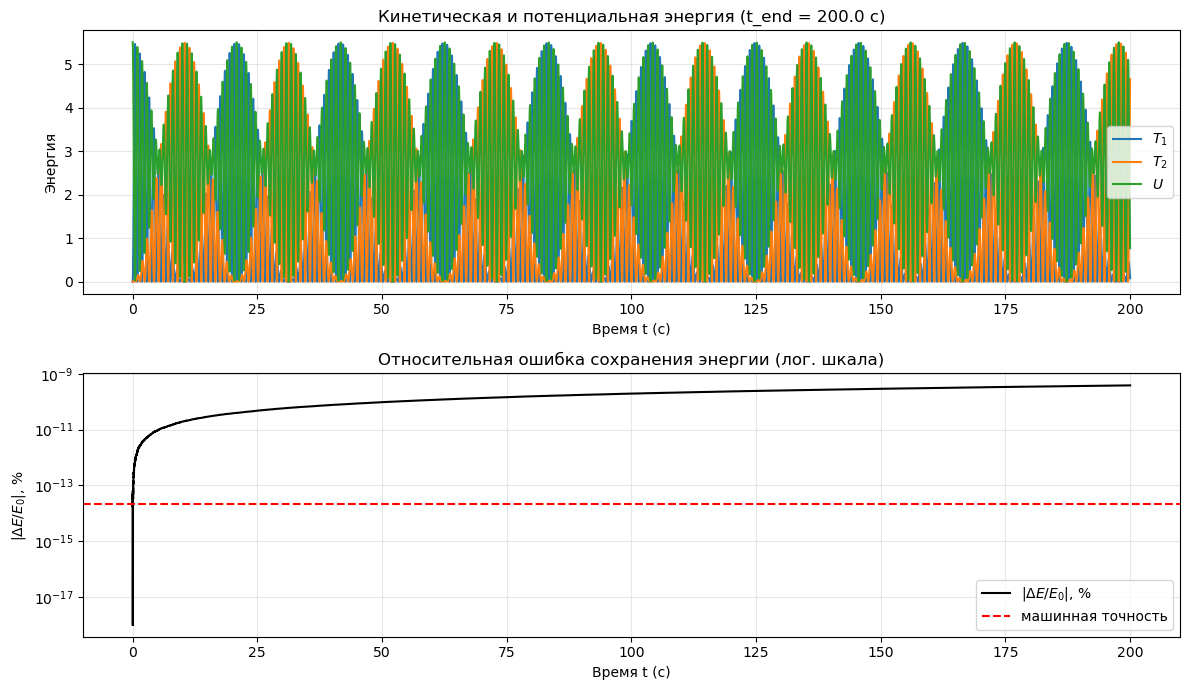

E0 = 5.500000000000
E_end = 5.499999999979
Относительное отклонение = -3.894e-10 %


In [12]:
dt_energy = 0.001
t_end_energy = 200.0
t_e, states_e = simulate(step_rk4, s0, dt_energy, t_end_energy)

x1_e, v1_e = states_e[:, 0], states_e[:, 1]
x2_e, v2_e = states_e[:, 2], states_e[:, 3]

T1 = 0.5 * m * v1_e**2
T2 = 0.5 * m * v2_e**2
U = 0.5 * k0 * (x1_e**2 + x2_e**2) + 0.5 * kc * (x1_e - x2_e)**2
E_total = T1 + T2 + U

plt.figure(figsize=(12, 7))
plt.subplot(2, 1, 1)
plt.plot(t_e, T1, label=r'$T_1$', color='tab:blue')
plt.plot(t_e, T2, label=r'$T_2$', color='tab:orange')
plt.plot(t_e, U, label=r'$U$', color='tab:green')
plt.xlabel('Время t (с)'); plt.ylabel('Энергия')
plt.title(f'Кинетическая и потенциальная энергия (t_end = {t_end_energy} с)')
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
rel_err_abs = np.abs((E_total - E_total[0]) / E_total[0]) * 100
rel_err_abs = np.where(rel_err_abs == 0, 1e-18, rel_err_abs)
plt.semilogy(t_e, rel_err_abs, color='black', label=r'$|\Delta E / E_0|$, %')
plt.axhline(2.2e-14, color='red', ls='--', label='машинная точность')
plt.xlabel('Время t (с)'); plt.ylabel(r'$|\Delta E / E_0|$, %')
plt.title('Относительная ошибка сохранения энергии (лог. шкала)')
plt.legend(); plt.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print(f"E0 = {E_total[0]:.12f}")
print(f"E_end = {E_total[-1]:.12f}")
print(f"Относительное отклонение = {(E_total[-1] - E_total[0])/E_total[0] * 100:.3e} %")